In [28]:
# Q1
import pandas as pd
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score, classification_report

# Sample dataset
data = {
'text':[
'I love machine learning',
'Python is amazing',
'I hate bugs',
'Machine learning is powerful',
'Debugging is frustrating',
'I enjoy coding',
'Errors make me angry',
'Programming is fun',
'I dislike slow computers',
'AI is fascinating'
],
'label':[1,1,0,1,0,1,0,1,0,1]
}

from sklearn.metrics import accuracy_score, classification_report

print("Accuracy:", accuracy_score(y_test, pred))
print(classification_report(y_test, pred, zero_division=0))

Accuracy: 0.5
              precision    recall  f1-score   support

           0       0.00      0.00      0.00         0
           1       1.00      0.50      0.67         2

    accuracy                           0.50         2
   macro avg       0.50      0.25      0.33         2
weighted avg       1.00      0.50      0.67         2



In [15]:
from google.colab import files
uploaded = files.upload()

Saving AirPassengers.csv to AirPassengers.csv


In [25]:
# Q2
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

df = pd.read_csv("AirPassengers.csv")

df['Month'] = pd.to_datetime(df['Month'])
df.set_index('Month', inplace=True)

print(df.head())

df.rename(columns={'Passengers':'y'}, inplace=True)

            Passengers
Month                 
1949-01-01         112
1949-02-01         118
1949-03-01         132
1949-04-01         129
1949-05-01         121


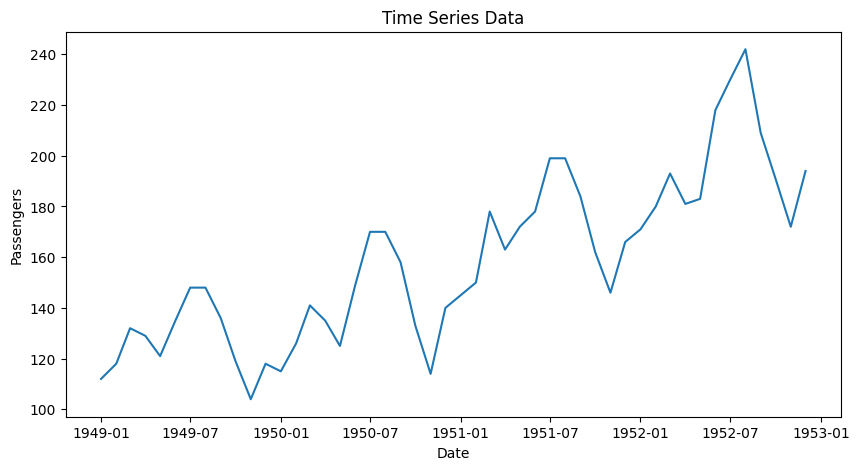

In [26]:
plt.figure(figsize=(10,5))
plt.plot(df['y'])
plt.title("Time Series Data")
plt.xlabel("Date")
plt.ylabel("Passengers")
plt.show()

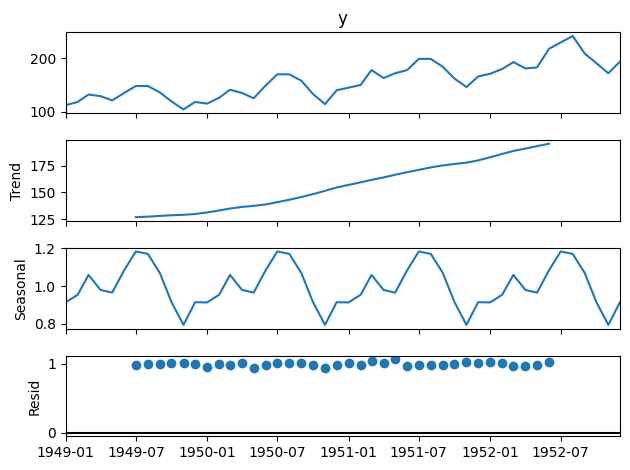

In [21]:
# Q3
from statsmodels.tsa.seasonal import seasonal_decompose

decompose = seasonal_decompose(df['y'], model='multiplicative')

decompose.plot()
plt.show()

In [22]:
# Q4
df['t'] = np.arange(len(df))

df['sin'] = np.sin(2*np.pi*df['t']/12)
df['cos'] = np.cos(2*np.pi*df['t']/12)

df.head()

,y,t,sin,cos
Month,,,,
1949-01-01,112,0,0.000000,1.000000e+00
1949-02-01,118,1,0.500000,8.660254e-01
1949-03-01,132,2,0.866025,5.000000e-01
1949-04-01,129,3,1.000000,6.123234e-17
1949-05-01,121,4,0.866025,-5.000000e-01


Lambda value: -0.1878959374990118


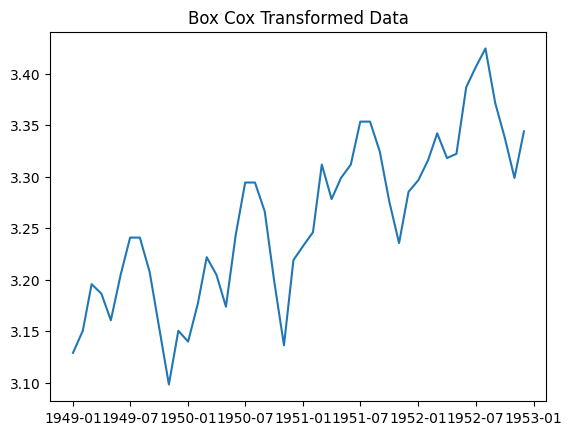

In [23]:
#Q5
from scipy.stats import boxcox

df['boxcox'], lam = boxcox(df['y'])

print("Lambda value:", lam)

plt.plot(df['boxcox'])
plt.title("Box Cox Transformed Data")
plt.show()

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


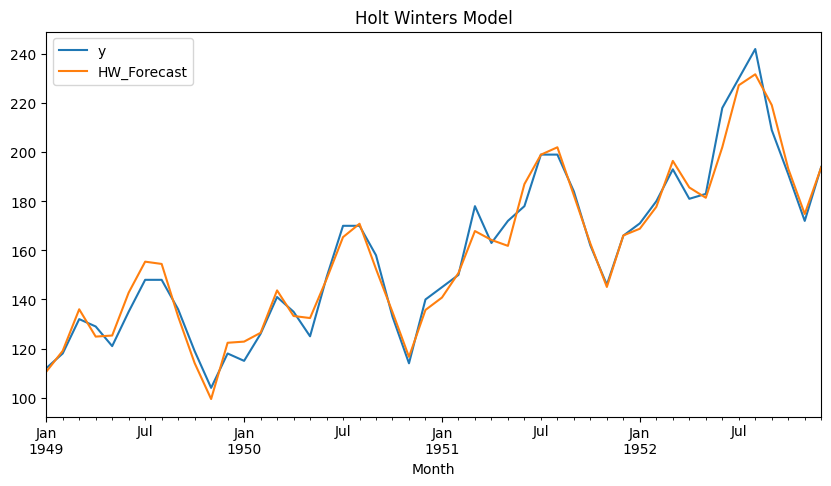

In [24]:
# Q6
from statsmodels.tsa.holtwinters import ExponentialSmoothing

model = ExponentialSmoothing(
        df['y'],
        trend='add',
        seasonal='add',
        seasonal_periods=12
        )

fit = model.fit()

df['HW_Forecast'] = fit.fittedvalues

df[['y','HW_Forecast']].plot(figsize=(10,5))
plt.title("Holt Winters Model")
plt.show()